## Tag Genome Dataset (2014) EDA
from GroupLens (MovieLens): https://grouplens.org/datasets/movielens/

To access the data, refer to instructions in `src/datapipeline/dataloader.py` and the respective section in the README.md file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Import libraries and load the data

In [10]:
movies = pd.read_csv("../data/movies.dat", sep='\t', header=None, names=["MovieID", "Title (Date)", "MoviePopularity"])
tags = pd.read_csv("../data/tags.dat", sep='\t', header=None, names=["TagID", "Tag Name", "TagPopularity"])
tag_relevance = pd.read_csv("../data/tag_relevance.dat", sep='\t', header=None, names=["MovieID", "TagID", "Relevance"])

In [11]:
print("Movies:")
display(movies.head())
print("\nTags:")
display(tags.head())
print("\nTag Relevance:")
display(tag_relevance.head())

Movies:


,MovieID,Title (Date),MoviePopularity
0,1,Toy Story (1995),53059
1,2,Jumanji (1995),22466
2,3,Grumpier Old Men (1995),15111
3,4,Waiting to Exhale (1995),2898
4,5,Father of the Bride Part II (1995),14323



Tags:


,TagID,Tag Name,TagPopularity
0,0,007,61
1,1,007 (series),24
2,2,18th century,37
3,3,1920s,42
4,4,1930s,55



Tag Relevance:


,MovieID,TagID,Relevance
0,1,0,0.032
1,1,1,0.035
2,1,2,0.070
3,1,3,0.114
4,1,4,0.105


#### Basic dataset inspection

In [12]:
print("Movies shape:", movies.shape)
print("Tags shape:", tags.shape)
print("Tag Relevance shape:", tag_relevance.shape)

print("\nMissing values:")
print(pd.concat({
    "Movies": movies.isnull().sum(),
    "Tags": tags.isnull().sum(),
    "TagRelevance": tag_relevance.isnull().sum()
}, axis=1))

print("\nData types:")
print(movies.dtypes, "\n")
print(tags.dtypes, "\n")
print(tag_relevance.dtypes)

Movies shape: (9734, 3)
Tags shape: (1128, 3)
Tag Relevance shape: (10979952, 3)

Missing values:
                 Movies  Tags  TagRelevance
MovieID             0.0   NaN           0.0
Title (Date)        0.0   NaN           NaN
MoviePopularity     0.0   NaN           NaN
TagID               NaN   0.0           0.0
Tag Name            NaN   0.0           NaN
TagPopularity       NaN   0.0           NaN
Relevance           NaN   NaN           0.0

Data types:
MovieID             int64
Title (Date)       object
MoviePopularity     int64
dtype: object 

TagID             int64
Tag Name         object
TagPopularity     int64
dtype: object 

MovieID        int64
TagID          int64
Relevance    float64
dtype: object


So we observe that there is no missing data in any of the datasets! (the NaN come from the fact that not all columns are present in all datasets).

#### Movie popularity distribution

/Users/mathilde/Desktop/S3/APCOMP215/Project/tarantAIno/taraintino_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


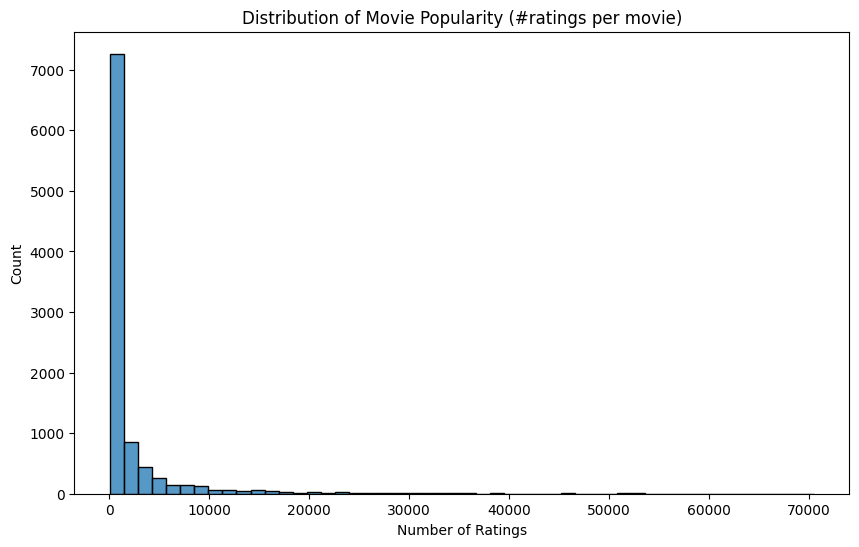

Top 10 most popular movies:


,MovieID,Title (Date),MoviePopularity
280,296,Pulp Fiction (1994),70567
338,356,Forrest Gump (1994),69786
558,593,"Silence of the Lambs, The (1991)",66777
302,318,"Shawshank Redemption, The (1994)",64442
455,480,Jurassic Park (1993),63344
245,260,Star Wars: Episode IV - A New Hope (1977),57440
106,110,Braveheart (1995),56102
0,1,Toy Story (1995),53059
555,589,Terminator 2: Judgment Day (1991),52464
137,150,Apollo 13 (1995),52402


In [16]:
plt.figure(figsize=(10,6))
sns.histplot(movies["MoviePopularity"], bins=50)
plt.title("Distribution of Movie Popularity (#ratings per movie)")
plt.xlabel("Number of Ratings")
plt.ylabel("Count")
plt.show()

top_movies = movies.sort_values(by="MoviePopularity", ascending=False).head(10)
print("Top 10 most popular movies:")
display(top_movies)

#### Tag popularity and examples

/Users/mathilde/Desktop/S3/APCOMP215/Project/tarantAIno/taraintino_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


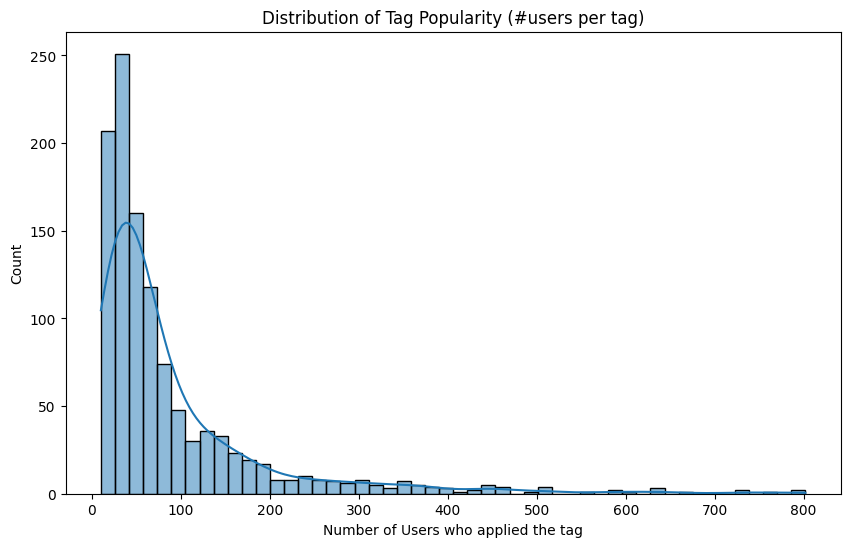

Top 10 most popular tags:


,TagID,Tag Name,TagPopularity
886,886,sci-fi,802
229,229,comedy,796
18,18,action,758
994,994,surreal,733
1049,1049,twist ending,728
416,416,funny,665
214,214,classic,637
85,85,atmospheric,633
285,285,dark comedy,630
862,862,romance,598


In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(tags["TagPopularity"], bins=50)
plt.title("Distribution of Tag Popularity (#users per tag)")
plt.xlabel("Number of Users who applied the tag")
plt.ylabel("Count")
# plt.xscale('log')
plt.show()

top_tags = tags.sort_values(by="TagPopularity", ascending=False).head(10)
print("Top 10 most popular tags:")
display(top_tags)

## Tag Relevance Distribution

/Users/mathilde/Desktop/S3/APCOMP215/Project/tarantAIno/taraintino_env/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


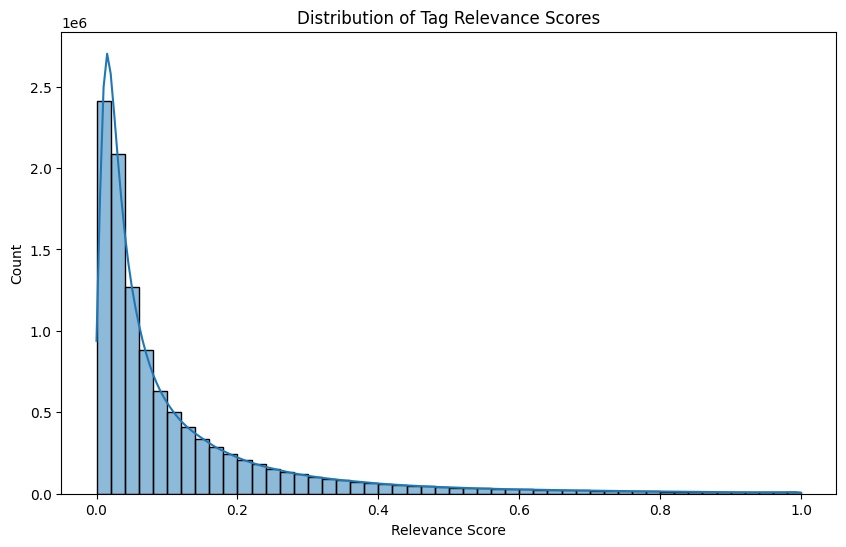

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(tag_relevance["Relevance"], bins=50)
plt.title("Distribution of Tag Relevance Scores")
plt.xlabel("Relevance Score")
plt.ylabel("Count")
plt.show()

So most tags aren't relevant. There is some interest in doing PCA, setting a relevance threshold or clustering (per similarity) on the tags to reduce dimensionality.